# ============================================
# AMAZON PRODUCT RECOMMENDATION SYSTEM
# ============================================
# Author: Abhinav Kumar
# Project Type: Recommendation System
# Dataset: Amazon Product Reviews
# ============================================

In [1]:
# ============================================
# INSTALL REQUIRED LIBRARIES
# ============================================

# Install compatible NumPy version
!pip install numpy==1.26.4

# Install recommendation system library
!pip install scikit-surprise==1.1.4

# Install dataset loader
!pip install kagglehub[pandas-datasets]

# Install visualization libraries
!pip install pandas matplotlib seaborn

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554978 sha256=08abe600c007146d66e6d1b2413810ebcaec49e5450aae6eb5deb420c318cca4
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [2]:
# ============================================
# CHECK LIBRARY VERSIONS
# ============================================

import numpy as np
import pandas as pd

print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

NumPy Version: 1.26.4
Pandas Version: 2.2.2


In [3]:
# ============================================
# IMPORT LIBRARIES
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle dataset loader
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Recommendation system
from surprise import Dataset
from surprise import Reader
from surprise import SVD

from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [4]:
# ============================================
# DOWNLOAD DATASET
# ============================================

path = kagglehub.dataset_download(
    "arhamrumi/amazon-product-reviews"
)

print("Dataset Path:", path)

100%|██████████| 115M/115M [00:00<00:00, 148MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1


In [5]:
# ============================================
# LIST DATASET FILES
# ============================================

import os

files = os.listdir(path)

print(files)

['Reviews.csv']


In [6]:
# ============================================
# LOAD DATASET
# ============================================

file_path = "Reviews.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arhamrumi/amazon-product-reviews",
    file_path
)

print(df.head())

/tmp/ipykernel_3891/3171756750.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'amazon-product-reviews' dataset.
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  

In [7]:
# Dataset shape

print(df.shape)

(568454, 10)


In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [9]:
# ============================================
# SELECT IMPORTANT COLUMNS
# ============================================

df = df[['UserId', 'ProductId', 'Score']]

In [10]:
# Rename columns

df.columns = ['user_id', 'product_id', 'rating']

print(df.head())

          user_id  product_id  rating
0  A3SGXH7AUHU8GW  B001E4KFG0       5
1  A1D87F6ZCVE5NK  B00813GRG4       1
2   ABXLMWJIXXAIN  B000LQOCH0       4
3  A395BORC6FGVXV  B000UA0QIQ       2
4  A1UQRSCLF8GW1T  B006K2ZZ7K       5


In [11]:
# ============================================
# CHECK MISSING VALUES
# ============================================

print(df.isnull().sum())

user_id       0
product_id    0
rating        0
dtype: int64


In [12]:
# ============================================
# REMOVE NULL VALUES
# ============================================

df.dropna(inplace=True)

In [13]:
# ============================================
# REDUCE DATASET SIZE
# ============================================

df = df.sample(
    50000,
    random_state=42
)

print(df.shape)

(50000, 3)


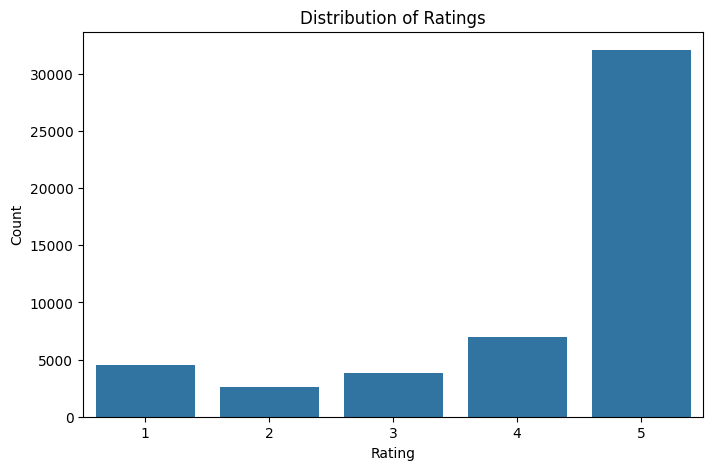

In [14]:
# ============================================
# RATING DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=df
)

plt.title("Distribution of Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

In [15]:
# ============================================
# MOST REVIEWED PRODUCTS
# ============================================

top_products = (
    df['product_id']
    .value_counts()
    .head(10)
)

print(top_products)

product_id
B007JFMH8M    84
B003B3OOPA    73
B0026RQTGE    67
B002QWHJOU    60
B000NMJWZO    57
B003GTR8IO    55
B007Y59HVM    55
B006HYLW32    54
B001RVFEP2    54
B005K4Q37A    54
Name: count, dtype: int64


In [16]:
# ============================================
# PREPARE DATA FOR MODEL
# ============================================

reader = Reader(
    rating_scale=(1,5)
)

data = Dataset.load_from_df(
    df[['user_id', 'product_id', 'rating']],
    reader
)

In [17]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [18]:
# ============================================
# TRAIN SVD MODEL
# ============================================

model = SVD()

model.fit(trainset)

In [19]:
# ============================================
# MAKE PREDICTIONS
# ============================================

predictions = model.test(testset)

In [20]:
# ============================================
# MODEL EVALUATION
# ============================================

rmse(predictions)

RMSE: 1.2754


1.2754042527892326

In [21]:
# ============================================
# SINGLE PREDICTION
# ============================================

user_id = df['user_id'].iloc[0]

product_id = df['product_id'].iloc[10]

prediction = model.predict(
    user_id,
    product_id
)

print(prediction)

user: A1L01D2BD3RKVO item: B005VOOL00 r_ui = None   est = 4.00   {'was_impossible': False}


In [22]:
# ============================================
# RECOMMENDATION FUNCTION
# ============================================

def recommend_product(user_id, product_id):

    prediction = model.predict(
        user_id,
        product_id
    )

    print(
        f"Estimated Rating: {prediction.est:.2f}"
    )

In [23]:
# ============================================
# TEST FUNCTION
# ============================================

recommend_product(
    df['user_id'].iloc[0],
    df['product_id'].iloc[20]
)

Estimated Rating: 4.20


In [24]:
# ============================================
# BUSINESS IMPACT
# ============================================

"""
Business Impact:

This recommendation system helps improve
customer experience by suggesting relevant
products based on user preferences and
historical ratings.

Potential Benefits:
- Increased cross-selling
- Higher conversion rates
- Improved customer engagement
- Better product discovery
"""

'\nBusiness Impact:\n\nThis recommendation system helps improve\ncustomer experience by suggesting relevant\nproducts based on user preferences and\nhistorical ratings.\n\nPotential Benefits:\n- Increased cross-selling\n- Higher conversion rates\n- Improved customer engagement\n- Better product discovery\n'